Neural Network in Python (Step-by-Step)

1. Import Libraries
import numpy as np

Prepare Data
X = [[1, 2, 3, 2.5],
     [2.0, 5.0, -1.0, 2.0],
     [-1.5, 2.7, 3.3, -0.8]]

y = [0, 1, 1]  # labels

👉 X = input data
👉 y = correct answers

3. Initialize Weights & Bias

weights = 0.01 * np.random.randn(4, 3)
biases = np.zeros((1, 3))

👉 weights = importance

👉 bias = adjustment

Weight tells how important an input is.

Bangla:

👉 Weight বলে দেয় কোন input কতটা গুরুত্বপূর্ণ

Bias is an extra value added to shift the output.

Bangla:

👉 Bias হলো extra value, যেটা output কে adjust করে

4. Forward Propagation (Main Calculation)

Z=XW+B

output = np.dot(X, weights) + biases

👉 input → multiply → add bias → output

Forward pass শুধু output দেয়

👉 কিন্তু learning হয় না

Activation Function

def relu(x):

    return np.maximum(0, x)

activated_output = relu(output)


Loss Calculation (Error)

loss = np.mean((activated_output - y)**2)

Backpropagation (Learning)

👉 Adjust weights based on error

(Simple idea)

error → gradient → update weights

Update Weights

weights -= 0.01 * gradient

biases -= 0.01 * gradient

Repeat (Training Loop)

for epoch in range(1000):
    # forward
    # loss
    # backward
    # update

👉 More iterations = better learning

Prediction
predictions = np.argmax(activated_output, axis=1)

Basic text classification

In [12]:
import matplotlib.pyplot as plt
import os
import re
import shutil
import string
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import losses
from tensorflow.keras import preprocessing
from tensorflow.keras.layers import TextVectorization


In [13]:
print(tf.__version__)

2.21.0


Download and explore the IMDB dataset

In [14]:
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

dataset = tf.keras.utils.get_file("aclImdb_v1", url,
                                    untar=True, cache_dir='.',
                                    cache_subdir='')

dataset_dir = os.path.join(os.getcwd(), 'aclImdb_v1_extracted')

In [15]:
print(dataset)

.\aclImdb_v1


In [16]:
print(os.listdir('.'))

['.idea', '.venv', '01.04.26.ipynb', '02.04.26.ipynb', '05.04.26.ipynb', '07.04.26.ipynb', '08.04.26.ipynb', '09.04.26.ipynb', '11.03.26.ipynb', '12.03.26.ipynb', '12.04.26.ipynb', '13.04.26.ipynb', '15.03.26.ipynb', '16.03.26.ipynb', '16.04.26 Backpropagation & Regression.ipynb', '21.04.2026.ipynb', '23.04.2026.ipynb', '29.03.26.ipynb', '30.03.26.ipynb', '31.03.26.ipynb', 'aclImdb', 'aclImdb_v1', 'aclImdb_v1.tar.gz', 'aclImdb_v1_archive', 'aclImdb_v1_extracted', 'clustering.ipynb', 'Customer Target', 'dnn_model.keras', 'DTC', 'DTR', 'extra.ipynb', 'global_fuel_prices_2020_2026.csv', 'image.jpg.jpeg', 'KMC', 'KNN', 'LR', 'MLR', 'NB', 'notebook.ipynb', 'notebook1.ipynb', 'notebook2.ipynb', 'OnlineRetail.csv.zip', 'PR', 'RF', 'RFC', 'SLR', 'SVR']


Open file and see the name of list

In [17]:
os.listdir(dataset_dir)

['aclImdb']

Create path and open file

In [18]:
dataset_dir = os.path.join(os.getcwd(), 'aclImdb_v1_extracted', 'aclImdb')
train_dir = os.path.join(dataset_dir, 'train')

print(os.listdir(train_dir))

['labeledBow.feat', 'neg', 'pos', 'unsupBow.feat', 'urls_neg.txt', 'urls_pos.txt', 'urls_unsup.txt']


Open and then close after reading by with

In [19]:

sample_file = os.path.join(train_dir, 'pos/1181_9.txt')
with open(sample_file) as f:
  print(f.read())

Rachel Griffiths writes and directs this award winning short film. A heartwarming story about coping with grief and cherishing the memory of those we've loved and lost. Although, only 15 minutes long, Griffiths manages to capture so much emotion and truth onto film in the short space of time. Bud Tingwell gives a touching performance as Will, a widower struggling to cope with his wife's death. Will is confronted by the harsh reality of loneliness and helplessness as he proceeds to take care of Ruth's pet cow, Tulip. The film displays the grief and responsibility one feels for those they have loved and lost. Good cinematography, great direction, and superbly acted. It will bring tears to all those who have lost a loved one, and survived.


Load the dataset

Permanenet Delete The file

In [21]:
remove_dir = os.path.join(train_dir, 'unsup')
shutil.rmtree(remove_dir)

FileNotFoundError: [WinError 2] The system cannot find the file specified: 'C:\\Users\\naimul.islam\\PyCharmMiscProject\\aclImdb_v1_extracted\\aclImdb\\train\\unsup'

Split data set and train then

In [22]:
batch_size = 32
seed = 42

raw_train_ds = tf.keras.preprocessing.text_dataset_from_directory(
    train_dir,
    batch_size=batch_size,
    validation_split=0.2,
    subset='training',
    seed=seed)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.


show dataset

In [23]:
for text_batch, label_batch in raw_train_ds.take(1):
  for i in range(3):
    print("Review", text_batch.numpy()[i])
    print("Label", label_batch.numpy()[i])

Review b'"Pandemonium" is a horror movie spoof that comes off more stupid than funny. Believe me when I tell you, I love comedies. Especially comedy spoofs. "Airplane", "The Naked Gun" trilogy, "Blazing Saddles", "High Anxiety", and "Spaceballs" are some of my favorite comedies that spoof a particular genre. "Pandemonium" is not up there with those films. Most of the scenes in this movie had me sitting there in stunned silence because the movie wasn\'t all that funny. There are a few laughs in the film, but when you watch a comedy, you expect to laugh a lot more than a few times and that\'s all this film has going for it. Geez, "Scream" had more laughs than this film and that was more of a horror film. How bizarre is that?<br /><br />*1/2 (out of four)'
Label 0
Review b"David Mamet is a very interesting and a very un-equal director. His first movie 'House of Games' was the one I liked best, and it set a series of films with characters whose perspective of life changes as they get into 

In [24]:
print("Label 0 corresponds to", raw_train_ds.class_names[0])
print("Label 1 corresponds to", raw_train_ds.class_names[1])

Label 0 corresponds to neg
Label 1 corresponds to pos


validation check for how perform

In [28]:
print(os.getcwd())

C:\Users\naimul.islam\PyCharmMiscProject


In [29]:
raw_val_ds = tf.keras.preprocessing.text_dataset_from_directory(
    'aclImdb_v1/aclImdb/train',
    batch_size=batch_size,
    validation_split=0.2,
    subset='validation',
    seed=seed)

Found 75000 files belonging to 3 classes.
Using 15000 files for validation.


Final test dataset create for model

In [31]:
raw_test_ds = tf.keras.preprocessing.text_dataset_from_directory(
    'aclImdb_v1/aclImdb/test',
    batch_size=batch_size)


Found 25000 files belonging to 2 classes.


Prepare the dataset for training

TextVectorization

In [35]:
def custom_standardization(input_data):
  lowercase = tf.strings.lower(input_data)
  stripped_html = tf.strings.regex_replace(lowercase, '<br />', ' ')
  return tf.strings.regex_replace(
      stripped_html,
      '[%s]' % re.escape(string.punctuation),
      '')

Text → Token → Number sequence

In [36]:
max_features = 10000
sequence_length = 250

vectorize_layer = TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length)

Make a text-only dataset (without labels), then call adapt

In [37]:
train_text = raw_train_ds.map(lambda x, y: x)
vectorize_layer.adapt(train_text)

See Result

In [38]:
def vectorize_text(text, label):
  text = tf.expand_dims(text, -1)
  return vectorize_layer(text), label

In [39]:
text_batch, label_batch = next(iter(raw_train_ds))
first_review, first_label = text_batch[0], label_batch[0]
print("Review", first_review)
print("Label", raw_train_ds.class_names[first_label])
print("Vectorized review", vectorize_text(first_review, first_label))

Review tf.Tensor(b'Silent Night, Deadly Night 5 is the very last of the series, and like part 4, it\'s unrelated to the first three except by title and the fact that it\'s a Christmas-themed horror flick.<br /><br />Except to the oblivious, there\'s some obvious things going on here...Mickey Rooney plays a toymaker named Joe Petto and his creepy son\'s name is Pino. Ring a bell, anyone? Now, a little boy named Derek heard a knock at the door one evening, and opened it to find a present on the doorstep for him. Even though it said "don\'t open till Christmas", he begins to open it anyway but is stopped by his dad, who scolds him and sends him to bed, and opens the gift himself. Inside is a little red ball that sprouts Santa arms and a head, and proceeds to kill dad. Oops, maybe he should have left well-enough alone. Of course Derek is then traumatized by the incident since he watched it from the stairs, but he doesn\'t grow up to be some killer Santa, he just stops talking.<br /><br />T

In [40]:
print("1287 ---> ",vectorize_layer.get_vocabulary()[1287])
print(" 313 ---> ",vectorize_layer.get_vocabulary()[313])
print('Vocabulary size: {}'.format(len(vectorize_layer.get_vocabulary())))

1287 --->  silent
 313 --->  night
Vocabulary size: 10000


Configure the dataset for performance

In [42]:
train_ds = raw_train_ds.map(vectorize_text)
val_ds = raw_val_ds.map(vectorize_text)
test_ds = raw_test_ds.map(vectorize_text)

In [43]:
AUTOTUNE = tf.data.experimental.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Create the model

In [45]:
embedding_dim = 16

In [46]:
model = tf.keras.Sequential([
  layers.Embedding(max_features + 1, embedding_dim),
  layers.Dropout(0.2),
  layers.GlobalAveragePooling1D(),
  layers.Dropout(0.2),
  layers.Dense(1)])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Loss function and optimizer

In [48]:
model.compile(loss=losses.BinaryCrossentropy(from_logits=True),
              optimizer='adam',
              metrics=[tf.metrics.BinaryAccuracy(threshold=0.0)])


Train the model

In [49]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 55ms/step - binary_accuracy: 0.6434 - loss: 0.6626 - val_binary_accuracy: 0.2490 - val_loss: 0.5724
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - binary_accuracy: 0.7780 - loss: 0.5469 - val_binary_accuracy: 0.2779 - val_loss: 0.7533
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - binary_accuracy: 0.8320 - loss: 0.4449 - val_binary_accuracy: 0.2855 - val_loss: 0.9132
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - binary_accuracy: 0.8578 - loss: 0.3817 - val_binary_accuracy: 0.2905 - val_loss: 1.0471
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - binary_accuracy: 0.8715 - loss: 0.3406 - val_binary_accuracy: 0.2947 - val_loss: 1.1702
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - binary_accuracy: 0.8816 - loss: 0.3102 - val_binary_accuracy: 0.2965 - val_loss: 1.3075
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - binary_accuracy: 0.8901 - loss: 0.2881 - val_binary_accuracy: 0.2991 - val_loss: 1.4165
Epoc


Evaluate the model

In [50]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 56ms/step - binary_accuracy: 0.8558 - loss: 0.3315
Loss:  0.331455260515213
Accuracy:  0.8558400273323059


Create a plot of accuracy and loss over time

In [51]:

history_dict = history.history
history_dict.keys()

dict_keys(['binary_accuracy', 'loss', 'val_binary_accuracy', 'val_loss'])

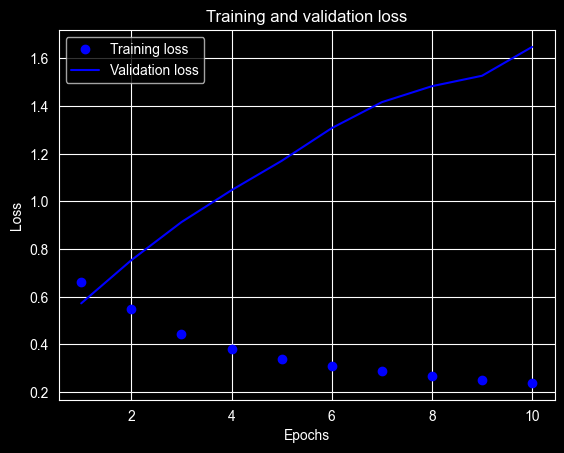

In [52]:
acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

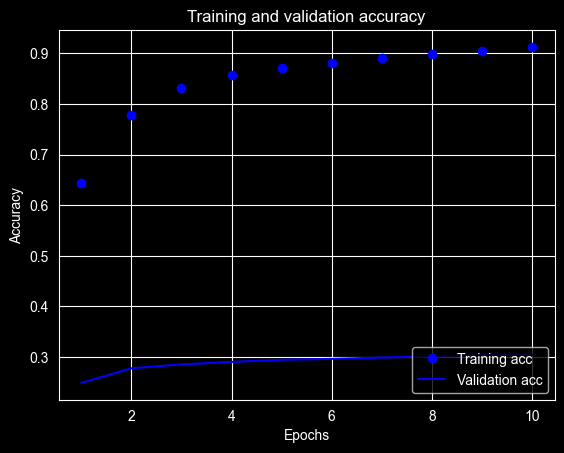

In [53]:

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()

Export the model

In [54]:
export_model = tf.keras.Sequential([
  vectorize_layer,
  model,
  layers.Activation('sigmoid')
])

export_model.compile(
    loss=losses.BinaryCrossentropy(from_logits=False), optimizer="adam", metrics=['accuracy']
)

# Test it with `raw_test_ds`, which yields raw strings
loss, accuracy = export_model.evaluate(raw_test_ds)
print(accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8558 - loss: 0.3315
0.8558400273323059


Inference on new data

In [57]:
examples = [
  "The movie was great!",
  "The movie was okay.",
  "The movie was terrible..."
]

export_model.predict(tf.constant(examples))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


array([[0.3433429 ],
       [0.1985997 ],
       [0.14341538]], dtype=float32)